# Block B: Preprocessing Pipeline (CTG)

Goal: Clean CTG signals (FHR, UC) to prepare for segmentation + feature extraction.

This notebook:
- Loads Block A outputs (`dataset_summary.csv`, `dataset_statistics.json`)
- Picks representative example records (Normal/Pathological/Unknown + failed-quality)
- Implements preprocessing:
  - FHR dropout handling (0 -> missing)
  - Outlier removal (FHR outside [80, 240] bpm)
  - Gap-limited interpolation
  - Gaussian smoothing
  - Optional z-score normalization (OFF for plots by default)
- Generates QC metrics + before/after plots
- Saves a small QC report for example records

Note: For visualization, we keep outputs in bpm/UC units (z-score OFF).
For CNN inputs later, you can turn z-score ON in Block C.



In [40]:
import json
import ast
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import wfdb
from scipy.ndimage import gaussian_filter1d



In [41]:
data_dir = Path("../data/ctu-chb-intrapartum-cardiotocography-database-1.0.0").resolve()
out_dir = Path("../outputs").resolve()
out_dir.mkdir(parents=True, exist_ok=True)

summary_csv = out_dir / "dataset_summary.csv"
stats_json = out_dir / "dataset_statistics.json"

dfA = pd.read_csv(summary_csv)
with open(stats_json, "r") as f:
    statsA = json.load(f)

print("Loaded Block A summary:", dfA.shape)
print("Example columns:", dfA.columns.tolist())
print("Unknown IDs:", statsA.get("unknown_record_ids", []))
print("Failed-quality IDs (n):", len(statsA.get("failed_quality_record_ids", [])))


Loaded Block A summary: (552, 22)
Example columns: ['record_id', 'num_signals', 'sampling_rate', 'num_samples', 'duration_seconds', 'duration_minutes', 'fhr_available', 'uc_available', 'mhr_available', 'outcome_label', 'outcomes_raw', 'sig_names_dbg', 'fhr_missing_pct', 'fhr_outliers_pct', 'fhr_valid_pct', 'uc_missing_pct', 'uc_outliers_pct', 'ph', 'apgar1', 'apgar5', 'label_source', 'quality_pass']
Unknown IDs: ['1002', '1017']
Failed-quality IDs (n): 10


In [42]:
unknown_ids = [str(x) for x in statsA.get("unknown_record_ids", [])]
failed_quality_ids = [str(x) for x in statsA.get("failed_quality_record_ids", [])]

example_ids = []

# One normal
normal_candidates = dfA.loc[dfA["outcome_label"] == "Normal", "record_id"].astype(str)
if len(normal_candidates) > 0:
    example_ids.append(normal_candidates.iloc[0])

# One pathological
path_candidates = dfA.loc[dfA["outcome_label"] == "Pathological", "record_id"].astype(str)
if len(path_candidates) > 0:
    example_ids.append(path_candidates.iloc[0])

# Unknown (if present)
if len(unknown_ids) > 0:
    example_ids.append(unknown_ids[0])

# Two failed-quality (if present)
example_ids += failed_quality_ids[:2]

# Ensure uniqueness & remove any NAs
example_ids = [x for x in dict.fromkeys(example_ids) if isinstance(x, str) and x.strip() != ""]

print("Example record_ids:", example_ids)


Example record_ids: ['1003', '1001', '1002', '1058', '1164']


In [43]:
def load_ctg_record(record_id: str, data_dir: Path):
    """
    Load CTU-CHB record via WFDB.
    Returns p_signal (N x C), fields, indices for FHR/UC, and fs.
    """
    rec_path = str((data_dir / str(record_id)).resolve())
    p_signal, fields = wfdb.rdsamp(rec_path)

    sig_names = [s.upper() for s in fields.get("sig_name", [])]

    def find_idx(keys):
        for i, name in enumerate(sig_names):
            for k in keys:
                if k in name:
                    return i
        return None

    fhr_idx = find_idx(["FHR", "FETAL"])
    uc_idx  = find_idx(["UC", "TOCO", "UA", "UTERINE"])

    fs = float(fields.get("fs", 4.0))
    return p_signal, fields, fhr_idx, uc_idx, fs

print("Record loader ready")


Record loader ready


In [44]:
FS_DEFAULT = 4.0

FHR_MIN, FHR_MAX = 80.0, 240.0
UC_MIN, UC_MAX = 0.0, 100.0

FHR_MISSING_SENTINEL = 0.0

MAX_INTERP_GAP_SEC = 30.0   # don't interpolate gaps longer than this
GAUSS_SIGMA_SEC = 1.5       # Gaussian smoothing sigma in seconds

# Important: z-score OFF for plots (so cleaned doesn't look "flat")
ZSCORE_FOR_PLOTS = False

print("Config set")



Config set


In [45]:
def runs_of_true(mask: np.ndarray):
    """Return start/end indices (end exclusive) for contiguous True runs."""
    if mask.size == 0:
        return np.array([], dtype=int), np.array([], dtype=int)
    m = mask.astype(np.int8)
    diff = np.diff(np.r_[0, m, 0])
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0]
    return starts, ends

def interp_nan_with_gap_limit(y: np.ndarray, max_gap_samples: int):
    """
    Linear interpolate NaNs but only fill NaN runs with length <= max_gap_samples.
    Longer gaps remain NaN.
    """
    y = np.asarray(y, dtype=float).copy()
    n = len(y)

    isnan = np.isnan(y)
    if not isnan.any():
        return y

    starts, ends = runs_of_true(isnan)

    x = np.arange(n)
    good = ~isnan
    if good.sum() < 2:
        return y

    y_interp = np.interp(x, x[good], y[good])

    for s, e in zip(starts, ends):
        if (e - s) <= max_gap_samples:
            y[s:e] = y_interp[s:e]

    return y

print("Interpolation utilities ready")


Interpolation utilities ready


In [46]:
def preprocess_fhr(
    fhr: np.ndarray,
    fs: float = FS_DEFAULT,
    fhr_min: float = FHR_MIN,
    fhr_max: float = FHR_MAX,
    missing_sentinel: float = FHR_MISSING_SENTINEL,
    max_interp_gap_sec: float = MAX_INTERP_GAP_SEC,
    gauss_sigma_sec: float = GAUSS_SIGMA_SEC,
    zscore_per_record: bool = False
):
    """
    FHR preprocessing:
      1) sentinel/NaN -> missing (NaN)
      2) outliers outside [fhr_min, fhr_max] -> NaN
      3) interpolate short gaps only (<= max_interp_gap_sec)
      4) Gaussian smoothing
      5) optional z-score normalization

    Returns:
      y_clean: np.ndarray (float) with NaNs preserved for long gaps
      qc: dict of pre/post quality metrics
    """
    y0 = np.asarray(fhr, dtype=float)
    y = y0.copy()
    n = len(y)

    # ---- 1) Missing sentinel / NaN ----
    sentinel_mask = (y == missing_sentinel)
    nan_mask0 = np.isnan(y)
    missing_mask0 = nan_mask0 | sentinel_mask
    y[missing_mask0] = np.nan

    # ---- 2) Outliers -> NaN ----
    outlier_mask = np.isfinite(y) & ((y < fhr_min) | (y > fhr_max))
    y[outlier_mask] = np.nan

    # ---- PRE metrics (after masking, before interp/smooth) ----
    pre_nan = np.isnan(y)  # includes sentinel+NaN+outlier
    pre_valid = ~pre_nan

    # longest NaN gap (pre)
    starts, ends = runs_of_true(pre_nan)
    pre_max_gap_samples = int(np.max(ends - starts)) if len(starts) else 0
    pre_max_gap_sec = pre_max_gap_samples / fs if fs else np.nan

    # component rates (pre)
    sentinel_pct = float(100.0 * sentinel_mask.mean()) if n else np.nan
    nan0_pct = float(100.0 * nan_mask0.mean()) if n else np.nan
    outlier_pct = float(100.0 * outlier_mask.mean()) if n else np.nan
    pre_nan_pct = float(100.0 * pre_nan.mean()) if n else np.nan
    pre_valid_pct = float(100.0 * pre_valid.mean()) if n else np.nan

    # ---- 3) Gap-limited interpolation ----
    max_fill = max(1, int(round(max_interp_gap_sec * fs))) if fs else 1

    # Only interpolate if we have enough valid points
    if np.isfinite(y).sum() >= 2:
        y = interp_nan_with_gap_limit(y, max_gap_samples=max_fill)
    # else: keep as-is (mostly NaNs)

    # ---- 4) Smoothing (Gaussian) ----
    sigma_samp = max(0.0, gauss_sigma_sec * fs) if fs else 0.0
    if sigma_samp > 0:
        if np.isnan(y).any():
            idx = np.arange(n)
            good = np.isfinite(y)
            if good.sum() >= 2:
                y_fill = np.interp(idx, idx[good], y[good])
            else:
                y_fill = np.nan_to_num(y, nan=0.0)
            y_smooth = gaussian_filter1d(y_fill, sigma=sigma_samp, mode="nearest")
            # preserve NaNs where we still have NaNs (long gaps)
            y_smooth[np.isnan(y)] = np.nan
            y = y_smooth
        else:
            y = gaussian_filter1d(y, sigma=sigma_samp, mode="nearest")

    # ---- 5) Optional z-score (post) ----
    if zscore_per_record:
        mu = np.nanmean(y)
        sd = np.nanstd(y)
        if np.isfinite(sd) and sd > 0:
            y = (y - mu) / sd
        else:
            y = y * 0.0

    # ---- POST metrics ----
    post_nan = np.isnan(y)
    post_nan_pct = float(100.0 * post_nan.mean()) if n else np.nan
    post_valid_pct = float(100.0 * (~post_nan).mean()) if n else np.nan

    starts2, ends2 = runs_of_true(post_nan)
    post_max_gap_samples = int(np.max(ends2 - starts2)) if len(starts2) else 0
    post_max_gap_sec = post_max_gap_samples / fs if fs else np.nan

    # How much missing was filled (cannot go negative)
    interp_filled_pct = None
    if np.isfinite(pre_nan_pct) and np.isfinite(post_nan_pct):
        interp_filled_pct = float(max(0.0, pre_nan_pct - post_nan_pct))

    qc = {
        "fs": float(fs),
        "n": int(n),

        # Source components (based on raw input)
        "fhr_sentinel_zero_pct": sentinel_pct,
        "fhr_nan_input_pct": nan0_pct,

        # Pre (after masking sentinel + outliers, before interp/smooth)
        "fhr_outliers_pct": outlier_pct,
        "fhr_missing_pct": pre_nan_pct,          # your original meaning (all NaNs pre)
        "fhr_valid_pct": pre_valid_pct,          # your original meaning (valid pre)
        "fhr_max_missing_gap_sec": float(pre_max_gap_sec),

        # Post (after interp + smooth)
        "fhr_remaining_nan_pct": post_nan_pct,
        "fhr_valid_pct_post": post_valid_pct,
        "fhr_max_missing_gap_sec_post": float(post_max_gap_sec),
        "interp_filled_pct": interp_filled_pct,

        # Params used
        "interp_max_gap_sec": float(max_interp_gap_sec),
        "gauss_sigma_sec": float(gauss_sigma_sec),
        "zscore_per_record": bool(zscore_per_record),
        "fhr_range_bpm": [float(fhr_min), float(fhr_max)],
    }

    return y, qc




In [47]:
def preprocess_uc(
    uc: np.ndarray,
    fs: float = FS_DEFAULT,
    uc_min: float = UC_MIN,
    uc_max: float = UC_MAX,
    gauss_sigma_sec: float = GAUSS_SIGMA_SEC,
    zscore_per_record: bool = False
):
    """
    UC preprocessing:
      1) outliers outside [uc_min, uc_max] -> NaN
      2) Gaussian smoothing
      3) optional z-score normalization
    Returns cleaned uc and QC dict.
    """
    y = np.asarray(uc, dtype=float).copy()
    n = len(y)

    missing = np.isnan(y)
    outliers = np.isfinite(y) & ((y < uc_min) | (y > uc_max))
    y[outliers] = np.nan

    sigma_samp = max(0.0, gauss_sigma_sec * fs)
    if sigma_samp > 0:
        if np.isnan(y).any():
            idx = np.arange(n)
            good = np.isfinite(y)
            if good.sum() >= 2:
                y_fill = np.interp(idx, idx[good], y[good])
            else:
                y_fill = np.nan_to_num(y, nan=0.0)
            y_smooth = gaussian_filter1d(y_fill, sigma=sigma_samp, mode="nearest")
            y_smooth[np.isnan(y)] = np.nan
            y = y_smooth
        else:
            y = gaussian_filter1d(y, sigma=sigma_samp, mode="nearest")

    if zscore_per_record:
        mu = np.nanmean(y)
        sd = np.nanstd(y)
        if np.isfinite(sd) and sd > 0:
            y = (y - mu) / sd
        else:
            y = y * 0.0

    qc = {
        "fs": float(fs),
        "n": int(n),
        "uc_missing_pct": float(100.0 * missing.mean()) if n else np.nan,
        "uc_outliers_pct": float(100.0 * outliers.mean()) if n else np.nan,
        "gauss_sigma_sec": float(gauss_sigma_sec),
        "zscore_per_record": bool(zscore_per_record),
    }
    return y, qc

print("UC preprocessing ready")


UC preprocessing ready


In [48]:
def preprocess_ctg(fhr, uc, fs, zscore=False):
    fhr_c, qc_fhr = preprocess_fhr(fhr, fs=fs, zscore_per_record=zscore)
    uc_c, qc_uc = preprocess_uc(uc, fs=fs, zscore_per_record=zscore)
    qc = {**qc_fhr, **qc_uc}
    return fhr_c, uc_c, qc

print("CTG wrapper ready")



CTG wrapper ready


In [49]:
def plot_before_after(t, raw, cleaned, title, ylabel):
    plt.figure(figsize=(12, 4))
    plt.plot(t, raw, label="Raw")
    plt.plot(t, cleaned, label="Cleaned")
    plt.title(title)
    plt.xlabel("Time (minutes)")
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_before_after_two_axes(t, raw, cleaned, title, y1, y2):
    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax1.plot(t, raw, label="Raw")
    ax1.set_xlabel("Time (minutes)")
    ax1.set_ylabel(y1)

    ax2 = ax1.twinx()
    ax2.plot(t, cleaned, label="Cleaned", alpha=0.8)
    ax2.set_ylabel(y2)

    ax1.set_title(title)
    fig.tight_layout()
    plt.show()

print("Plot helpers ready")



Plot helpers ready


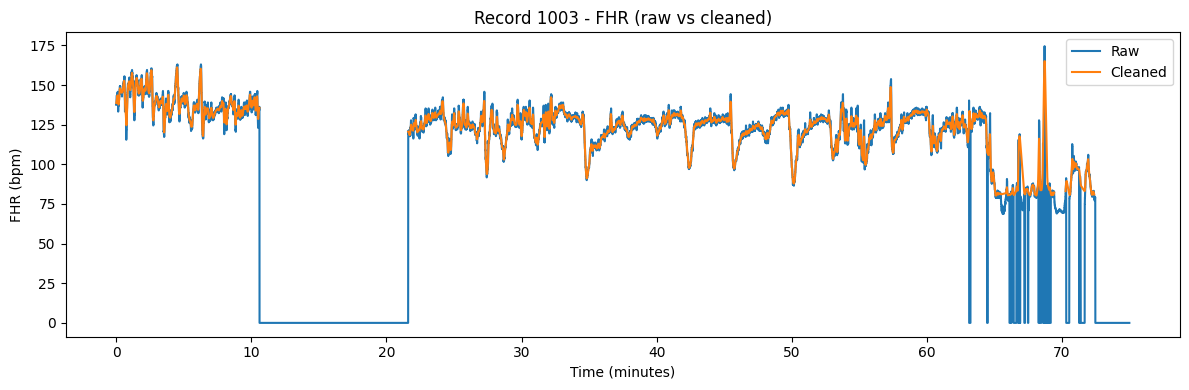

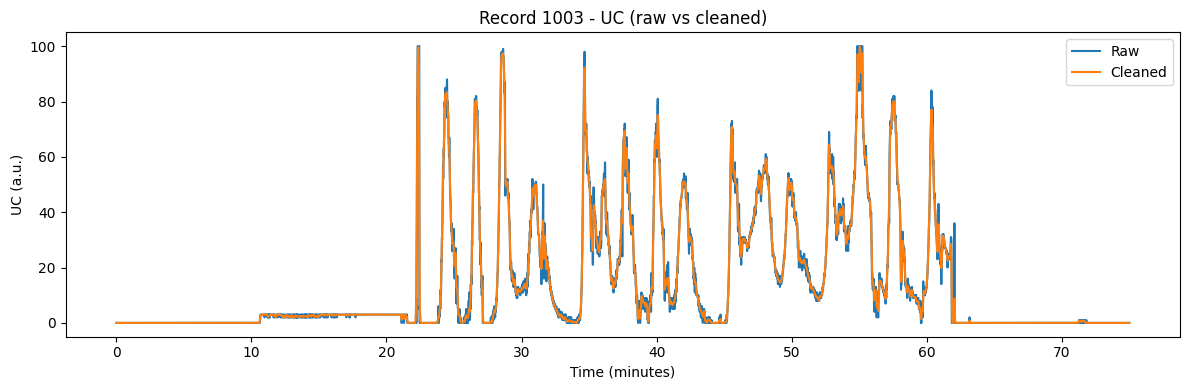

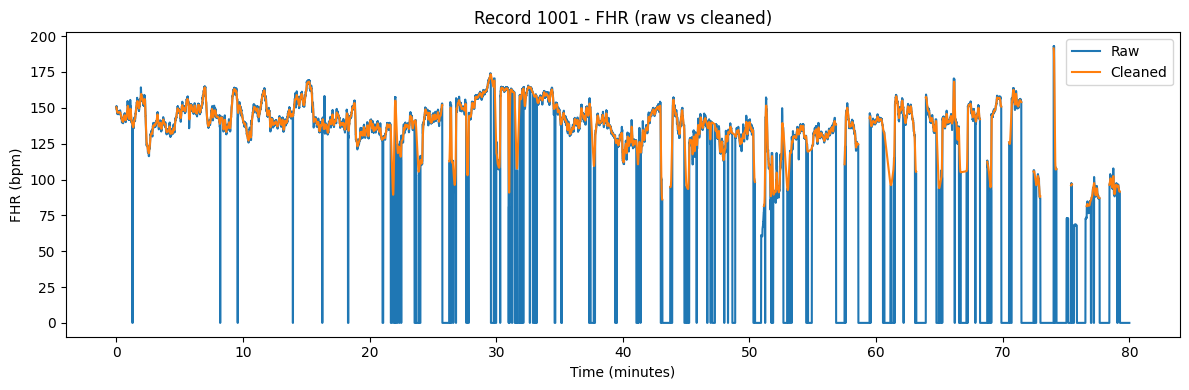

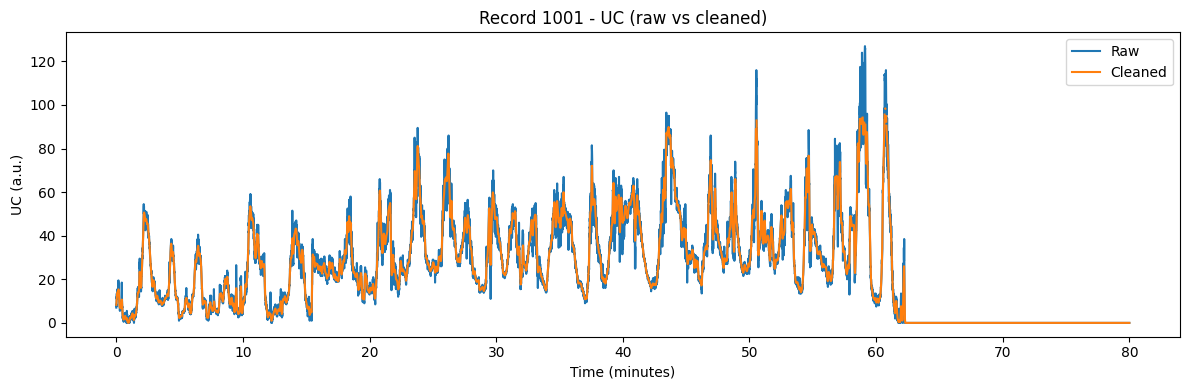

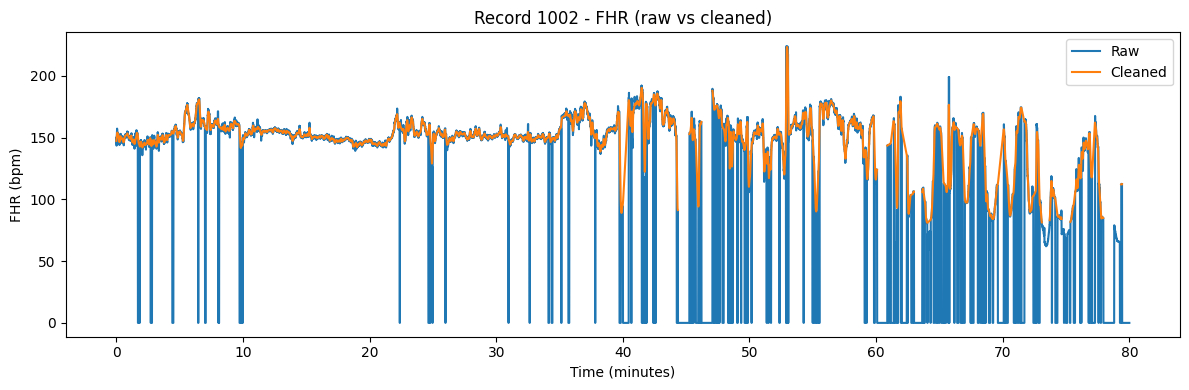

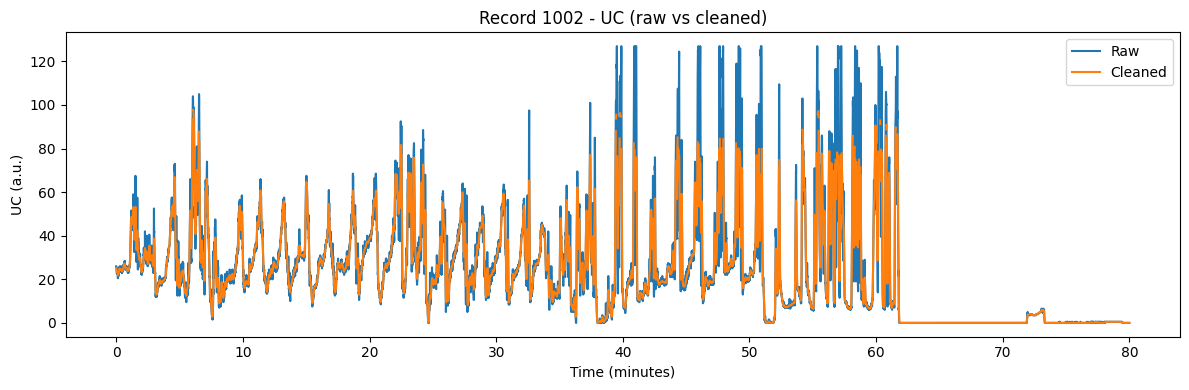

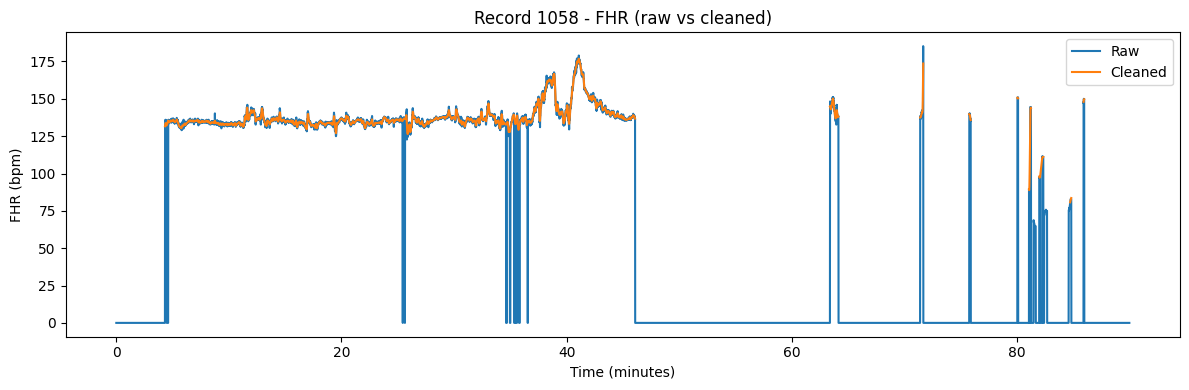

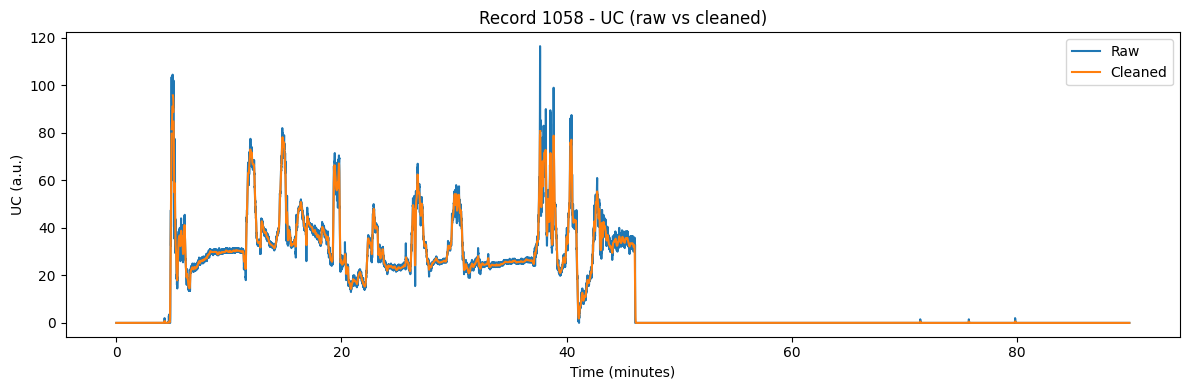

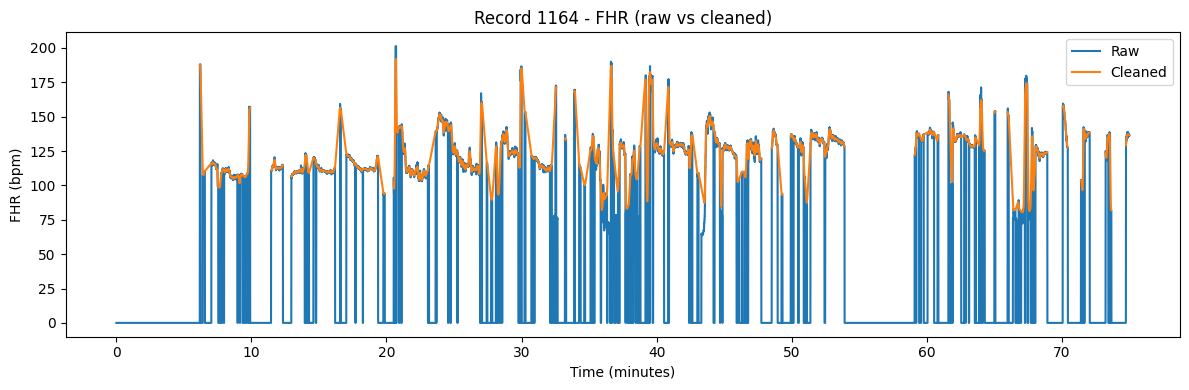

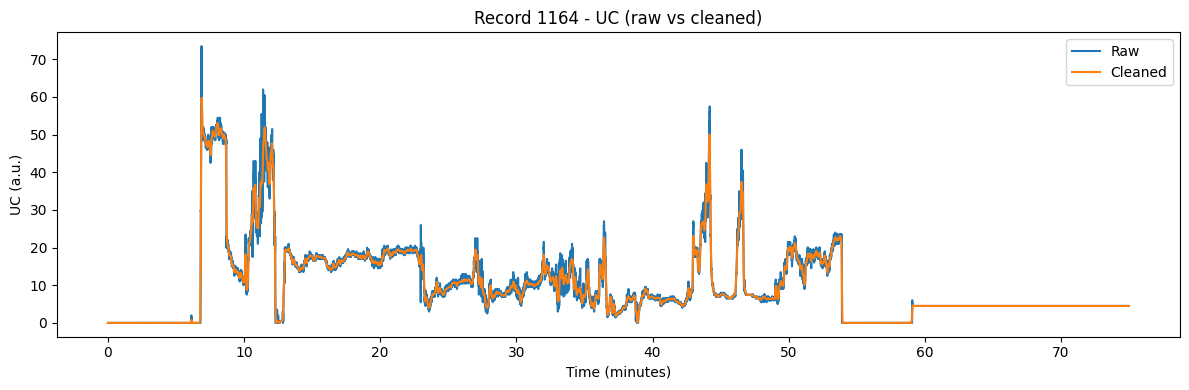

,fs,n,fhr_sentinel_zero_pct,fhr_nan_input_pct,fhr_outliers_pct,fhr_missing_pct,fhr_valid_pct,fhr_max_missing_gap_sec,fhr_remaining_nan_pct,fhr_valid_pct_post,fhr_max_missing_gap_sec_post,interp_filled_pct,interp_max_gap_sec,gauss_sigma_sec,zscore_per_record,fhr_range_bpm,uc_missing_pct,uc_outliers_pct,record_id
0,4.0,18000,20.477778,0.0,3.027778,23.505556,76.494444,660.50,19.266667,80.733333,660.50,4.238889,30.0,1.5,False,"[80.0, 240.0]",0.0,0.000000,1003
1,4.0,19200,22.161458,0.0,1.140625,23.302083,76.697917,69.75,14.052083,85.947917,69.75,9.250000,30.0,1.5,False,"[80.0, 240.0]",0.0,0.500000,1001
2,4.0,19200,16.984375,0.0,2.510417,19.494792,80.505208,84.50,8.166667,91.833333,84.50,11.328125,30.0,1.5,False,"[80.0, 240.0]",0.0,2.166667,1002
3,4.0,21600,51.648148,0.0,0.657407,52.305556,47.694444,1038.75,51.439815,48.560185,1038.75,0.865741,30.0,1.5,False,"[80.0, 240.0]",0.0,0.060185,1058
4,4.0,18000,49.083333,0.0,2.205556,51.288889,48.711111,371.00,31.405556,68.594444,371.00,19.883333,30.0,1.5,False,"[80.0, 240.0]",0.0,0.000000,1164


In [50]:
qc_rows = []

for rid in example_ids:
    p_signal, fields, fhr_idx, uc_idx, fs = load_ctg_record(rid, data_dir)
    if fhr_idx is None or uc_idx is None:
        print(f"[{rid}] Missing FHR/UC. fhr_idx={fhr_idx}, uc_idx={uc_idx}")
        continue

    fhr_raw = p_signal[:, fhr_idx]
    uc_raw  = p_signal[:, uc_idx]

    # For plots keep bpm/units (zscore=False)
    fhr_c, uc_c, qc = preprocess_ctg(fhr_raw, uc_raw, fs=fs, zscore=ZSCORE_FOR_PLOTS)

    qc["record_id"] = str(rid)
    qc_rows.append(qc)

    t_min = np.arange(len(fhr_raw)) / fs / 60.0

    plot_before_after(t_min, fhr_raw, fhr_c, f"Record {rid} - FHR (raw vs cleaned)", "FHR (bpm)")
    plot_before_after(t_min, uc_raw,  uc_c,  f"Record {rid} - UC (raw vs cleaned)",  "UC (a.u.)")

qc_df = pd.DataFrame(qc_rows)
qc_df



In [51]:
if len(qc_df) > 0:
    cols = [
        "record_id",
        "fhr_missing_pct",
        "fhr_outliers_pct",
        "fhr_valid_pct",
        "fhr_max_missing_gap_sec",
        "uc_outliers_pct",
    ]
    print(qc_df[cols].to_string(index=False))
else:
    print("No QC rows produced.")



record_id  fhr_missing_pct  fhr_outliers_pct  fhr_valid_pct  fhr_max_missing_gap_sec  uc_outliers_pct
     1003        23.505556          3.027778      76.494444                   660.50         0.000000
     1001        23.302083          1.140625      76.697917                    69.75         0.500000
     1002        19.494792          2.510417      80.505208                    84.50         2.166667
     1058        52.305556          0.657407      47.694444                  1038.75         0.060185
     1164        51.288889          2.205556      48.711111                   371.00         0.000000


In [52]:
qc_out_path = out_dir / "blockB_example_qc.csv"
qc_df.to_csv(qc_out_path, index=False)
print("Saved:", qc_out_path)



Saved: /home/naem_haq/projects/CTG/outputs/blockB_example_qc.csv


## Notes / Next Steps

- This notebook visualizes preprocessing with z-score OFF to keep units intuitive.
- In Block C you can:
  - preprocess with z-score OFF for RF feature extraction (features are in bpm/units)
  - preprocess with z-score ON for CNN inputs (stable scaling)

Recommended in Block C:
- Compute per-window valid FHR percentage and drop low-quality windows (e.g., <60–70%).
- Never split train/test at the segment level; split by recording_id to avoid leakage.
